# Project 2: Customer Segmentation & RFM Analysis
## Austin Airbnb Host Portfolio

**Analyst framing.** Airbnb operates as a two-sided marketplace. While guests generate bookings, hosts supply the inventory that makes the platform viable. This analysis treats **hosts as Airbnb's customers** — applying RFM segmentation and K-Means clustering to the Austin host base to identify retention risks, revenue concentrations, and growth opportunities.

**Business questions addressed**
- Which hosts constitute the top revenue tier, and how concentrated is marketplace value?
- Which previously-active hosts show signs of disengagement and warrant retention outreach?
- Which host segments represent underdeveloped growth potential?

**Methodology**
1. Data loading and RFM-relevant column audit
2. Host-level aggregation and raw RFM calculation
3. Quintile scoring
4. Rule-based segmentation
5. K-Means clustering with silhouette-based k selection
6. Segment profiling
7. Business recommendations

**Dataset.** `data/listings_clean.csv` — 10,402 Austin listings, cleaned via Project 1 pipeline. Source: [Inside Airbnb](http://insideairbnb.com/austin).

## 1. Data Loading & Initial Inspection

Objective: verify dataset structure, confirm presence and quality of columns required for RFM construction, and surface any data-quality issues that will affect methodology decisions in Section 2.

In [1]:
# Core data stack
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utility
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display configuration
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Visualization defaults — IBCS-inspired minimal styling
sns.set_style("white")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"Pandas version:       {pd.__version__}")
print(f"NumPy version:        {np.__version__}")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas version:       2.2.3
NumPy version:        2.2.4
Notebook initialized: 2026-04-19 13:25


In [2]:
# Load the cleaned listings dataset from Project 1
df = pd.read_csv('data/listings_clean.csv')

print(f"Shape:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(3)

Shape:  10,402 rows × 54 columns
Memory: 7.93 MB


,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_30,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_cleanliness,review_scores_location,instant_bookable,calculated_host_listings_count,reviews_per_month,host_experience_years,has_wifi,has_kitchen,has_free_parking,has_paid_parking,has_ac,has_washer,has_outdoor_dining,has_pets_allowed,has_bbq,has_fire_pit,has_private_entrance,has_pool,has_gym,has_ev_charger,has_hot_tub,amenity_count,price_per_bedroom,is_new_listing
0,5456,"Walk to 6th, Rainey St and Convention Ctr",8028,Sylvia,2009-02-16,within a few hours,100.00,90.00,True,True,78702,30.26,-97.73,Entire guesthouse,Entire home/apt,3,1.00,1.00,2.00,97.00,2,13,328,708,25,150,"14,550.00",2009-03-19,2025-09-02,4.85,4.86,4.73,f,1,3.52,17.20,True,True,False,False,True,False,False,False,False,False,True,False,False,False,False,26,97.00,False
1,6448,"Secluded Studio @ Zilker - King Bed, Bright & ...",14156,Amy,2009-04-20,within an hour,100.00,96.00,True,True,78704,30.26,-97.76,Entire guesthouse,Entire home/apt,2,1.00,1.00,2.00,160.00,3,12,316,339,14,84,"13,440.00",2011-09-06,2025-08-20,4.97,4.96,4.97,t,1,1.98,17.00,True,True,True,False,True,True,True,False,False,False,True,False,False,False,False,61,160.00,False
2,8502,Woodland Studio Lodging,25298,Karen,2009-07-11,within a day,100.00,60.00,False,False,78741,30.23,-97.74,Entire guest suite,Entire home/apt,2,1.00,1.00,1.00,38.00,4,29,88,54,1,8,304.00,2010-02-19,2025-05-05,4.57,4.67,4.69,f,1,0.28,16.80,True,True,False,False,True,False,False,True,False,False,False,False,False,False,False,12,38.00,False


In [3]:
# Columns required for RFM construction, plus contextual fields
rfm_columns = [
    'host_id',                          # Grouping key — one host = one customer
    'host_name',                        # Interpretability for segment profiles
    'last_review',                      # Recency source
    'first_review',                     # Host tenure context
    'number_of_reviews',                # Frequency: lifetime reviews
    'number_of_reviews_ltm',            # Frequency: trailing 12 months
    'reviews_per_month',                # Frequency: activity rate
    'price',                            # Contextual pricing
    'estimated_revenue_l365d',          # Monetary: pre-computed annual revenue proxy
    'estimated_occupancy_l365d',        # Monetary: bookable-night volume
    'calculated_host_listings_count',   # Portfolio size
    'availability_365',                 # Capacity context
    'is_new_listing'                    # Flag: listings with no review history
]

# Verify presence
missing = [c for c in rfm_columns if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# Column-level audit
audit = pd.DataFrame({
    'dtype': df[rfm_columns].dtypes.astype(str),
    'non_null': df[rfm_columns].notna().sum(),
    'nulls': df[rfm_columns].isna().sum(),
    'null_pct': (df[rfm_columns].isna().sum() / len(df) * 100).round(2)
})
audit

,dtype,non_null,nulls,null_pct
host_id,int64,10402,0,0.00
host_name,object,10402,0,0.00
last_review,object,10402,0,0.00
first_review,object,10402,0,0.00
number_of_reviews,int64,10402,0,0.00
number_of_reviews_ltm,int64,10402,0,0.00
reviews_per_month,float64,10402,0,0.00
price,float64,10402,0,0.00
estimated_revenue_l365d,float64,10402,0,0.00
estimated_occupancy_l365d,int64,10402,0,0.00


**Column availability and data integrity.** All thirteen RFM-relevant columns are present in the dataset, with zero null values recorded across 10,402 observations. No imputation, dropping, or flagging of missing values is required before proceeding to the aggregation stage. This level of completeness is unusual for raw marketplace data and reflects the cleaning work completed in Project 1.

**Data type observations.** Numeric fields (`number_of_reviews`, `price`, `estimated_revenue_l365d`, etc.) are correctly typed as integers or floats and require no conversion. The boolean flag `is_new_listing` is properly typed. However, the two date fields — `last_review` and `first_review` — are stored as `object` (string) type. Datetime conversion will be required before Recency can be calculated in days. This conversion will be handled in Section 2.

**Forward-looking consideration.** While null counts are clean, the `last_review` field contains a placeholder value (`"No reviews yet"`) for listings with no review history. This placeholder does not register as a null but behaves as one functionally, and will require explicit handling during datetime conversion.

In [4]:
# Host-level concentration
n_listings = len(df)
n_hosts = df['host_id'].nunique()
avg_listings_per_host = n_listings / n_hosts

print("Host-level concentration")
print("-" * 40)
print(f"Total listings:      {n_listings:,}")
print(f"Unique hosts:        {n_hosts:,}")
print(f"Avg listings/host:   {avg_listings_per_host:.2f}")

# Date range of review activity (excluding placeholder "No reviews yet")
valid_reviews = df.loc[df['last_review'] != 'No reviews yet', 'last_review']
lr = pd.to_datetime(valid_reviews, errors='coerce')

print("\nReview date range")
print("-" * 40)
print(f"Earliest last_review:  {lr.min().date()}")
print(f"Latest last_review:    {lr.max().date()}")
print(f"Listings with reviews: {len(valid_reviews):,}")
print(f"Listings without:      {(df['last_review'] == 'No reviews yet').sum():,}")

Host-level concentration
----------------------------------------
Total listings:      10,402
Unique hosts:        5,503
Avg listings/host:   1.89

Review date range
----------------------------------------
Earliest last_review:  2011-03-21
Latest last_review:    2025-09-16
Listings with reviews: 8,850
Listings without:      1,552


**Host concentration.** The dataset contains 10,402 listings distributed across 5,503 unique hosts, yielding an average of 1.89 listings per host. This confirms that a substantial share of listings belong to multi-property hosts, validating the decision to aggregate analysis to the host level rather than analyzing listings independently. From a marketplace perspective, losing a single multi-property host represents a materially larger retention risk than losing an individual listing — an asymmetry that listing-level analysis would obscure.

**Review activity window.** The earliest recorded review in the dataset occurred on 2011-03-21 and the most recent on 2025-09-16. This fourteen-year window captures Airbnb's full Austin market lifecycle, including pre-pandemic growth, the 2020 disruption, and the subsequent recovery. The latest date, **2025-09-16, establishes the reference point for Recency calculation** — all host recency scores will be measured as days elapsed from this snapshot date to each host's most recent review.

**Coverage of review-based metrics.** Of the 10,402 listings, 8,850 (85.1%) have review history and can contribute directly to Recency and Frequency calculations. The remaining 1,552 listings (14.9%) have never been reviewed and are flagged as new listings. The treatment of these listings within the RFM framework is the central methodology decision to be formalized in Section 2, with three candidate approaches: exclusion, inclusion with a maximum-recency penalty, or segmentation as a distinct new-host cohort.

## 2. Host-Level RFM Calculation

### Objective
Transform listing-level data (10,402 rows) into host-level RFM values (one row per unique host), producing the foundational dataset for all subsequent scoring, segmentation, and clustering work.

### Methodology Decisions

**Unit of analysis — host, not listing.** Airbnb's retention economics operate at the host level. A single multi-property host represents materially different churn risk than several independent hosts owning one listing each. Aggregating to `host_id` preserves this distinction and aligns the analysis with the business question.

**Treatment of listings without review history.** Of 10,402 listings, 1,552 (14.9%) have never been reviewed. These are excluded from the core RFM analysis and treated as a separate **New Host Cohort** reported later in the notebook. The reasoning is analytical, not technical:

- A host whose listings were once active and went dormant is a **retention problem**
- A host whose listing has never been reviewed is an **activation problem**
- Both may share identical RFM inputs under a "penalty" approach, but require opposite business interventions

Segmenting them separately preserves the integrity of the main RFM distributions and honors the distinction between churn risk and onboarding opportunity.

**Host-level aggregation rules.**

| Dimension | Source Column | Aggregation Rule | Rationale |
|---|---|---|---|
| Recency | `last_review` | `max()` across host's listings | A host with any recent activity is "alive" — most recent signal defines the relationship |
| Frequency | `number_of_reviews` | `sum()` across host's listings | Total engagement across the portfolio reflects operational activity |
| Monetary | `estimated_revenue_l365d` | `sum()` across host's listings | Total platform revenue generated |

**Reference date for Recency.** The snapshot date for recency calculation is the **latest `last_review` observed in the dataset: 2025-09-16**. This is preferable to using the current system date because the dataset represents a fixed historical snapshot — using today's date would artificially inflate all recency values.

### Deliverables
- `df_active` — listings with review history (8,850 rows)
- `df_new` — listings flagged as new (1,552 rows, deferred to New Host Cohort section)
- `rfm` — host-level RFM dataset, one row per unique host with review history

In [6]:
# Separate listings with review history from new listings.
# The main RFM analysis proceeds on df_active.
# df_new is retained for the New Host Cohort analysis later in the notebook.

df_active = df[df['is_new_listing'] == False].copy()
df_new    = df[df['is_new_listing'] == True].copy()

# Convert last_review to proper datetime dtype for downstream arithmetic
df_active['last_review'] = pd.to_datetime(df_active['last_review'])

print("Dataset split")
print("-" * 40)
print(f"Active listings (with reviews):   {len(df_active):,}")
print(f"New listings (no review history): {len(df_new):,}")
print(f"Total:                            {len(df_active) + len(df_new):,}")

print("\nActive listings — unique hosts")
print("-" * 40)
print(f"Unique hosts in df_active: {df_active['host_id'].nunique():,}")

Dataset split
----------------------------------------
Active listings (with reviews):   8,850
New listings (no review history): 1,552
Total:                            10,402

Active listings — unique hosts
----------------------------------------
Unique hosts in df_active: 4,829


**Split outcome.** The dataset separates cleanly into 8,850 active listings and 1,552 new listings, matching the pre-split diagnostic from Section 1 with no loss of rows. The active subset represents 85.1% of total marketplace inventory and forms the foundation for the main RFM analysis.

**Host base for RFM scoring.** The 8,850 active listings map to **4,829 unique hosts**, compared to 5,503 unique hosts across the full dataset. This implies that **674 hosts operate exclusively new listings** — they have no review history on any of their properties and will appear only in the New Host Cohort analysis. The remaining 4,829 hosts have at least one reviewed listing and will receive an RFM profile.

**Analytical implication.** The average of 1.83 active listings per host (8,850 ÷ 4,829) is slightly below the overall dataset average of 1.89. This indicates that multi-property hosts are marginally more likely to have review history across their portfolio than single-property hosts — a pattern consistent with professional operators who have been on the platform longer.

In [7]:
# Set the reference date for recency calculation.
# Using the dataset's latest last_review (not today's date) because the data
# represents a fixed snapshot — using today's date would artificially inflate
# recency values for all hosts.
SNAPSHOT_DATE = df_active['last_review'].max()
print(f"Snapshot date: {SNAPSHOT_DATE.date()}\n")

# Aggregate to host level.
# Recency  — max(last_review) per host, then converted to days elapsed
# Frequency — sum of lifetime reviews across host's active listings
# Monetary  — sum of estimated annual revenue across host's active listings
rfm = df_active.groupby('host_id').agg(
    host_name       = ('host_name', 'first'),
    listings_count  = ('host_id', 'size'),
    last_review     = ('last_review', 'max'),
    frequency       = ('number_of_reviews', 'sum'),
    monetary        = ('estimated_revenue_l365d', 'sum')
).reset_index()

# Convert last_review date to recency in days
rfm['recency'] = (SNAPSHOT_DATE - rfm['last_review']).dt.days

# Reorder columns for readability
rfm = rfm[['host_id', 'host_name', 'listings_count',
           'recency', 'frequency', 'monetary', 'last_review']]

print(f"Host-level RFM dataset shape: {rfm.shape}")
print(f"Unique hosts:                 {rfm['host_id'].nunique():,}\n")
rfm.head(10)

Snapshot date: 2025-09-16

Host-level RFM dataset shape: (4829, 7)
Unique hosts:                 4,829



,host_id,host_name,listings_count,recency,frequency,monetary,last_review
0,23,Charlene,3,331,59,828.00,2024-10-20
1,796,Betty,1,9,64,"12,528.00",2025-09-07
2,8028,Sylvia,1,14,708,"14,550.00",2025-09-02
3,12409,Flip,1,15,65,"5,712.00",2025-09-01
4,12449,Solcrisalva Yasmin,1,9,7,"8,694.00",2025-09-07
5,14156,Amy,1,27,339,"13,440.00",2025-08-20
6,21279,Eric,1,68,22,"1,392.00",2025-07-10
7,25298,Karen,1,134,54,304.00,2025-05-05
8,37329,Jill,1,188,12,"1,530.00",2025-03-12
9,44487,Christina F,2,14,1070,"58,044.00",2025-09-02


**Host-level RFM dataset produced.** The aggregation yields 4,829 unique host records, one row per host with review history. Each record now carries three normalized RFM measures alongside contextual fields (host name, portfolio size, raw last-review date for traceability).

**Reference date confirmed.** The snapshot date `2025-09-16` anchors the Recency calculation. All Recency values represent the number of days between a host's most recent review across any of their listings and this snapshot date. Lower Recency values indicate more recent activity.

**Preview observations.** The first ten rows span a meaningful range of host profiles — from small operators with single listings and modest revenue (e.g., Karen at \\$4,304 annual revenue) to established multi-property hosts with substantial portfolios (e.g., Christina F at \\$58,044 across two listings, 1,410 lifetime reviews). This heterogeneity is the signal that segmentation is designed to surface. The wide dispersion across all three dimensions previewed in this sample suggests the scoring and clustering stages will produce distinct, interpretable segments rather than collapse into a single dominant cluster.

**Readiness for scoring.** The RFM dataset is now structurally complete. Before applying scoring logic in Section 3, the shape of each dimension must be examined — done below.

In [8]:
# Summary statistics on the three RFM dimensions.
# The shape of these distributions (normal, skewed, bimodal) determines
# whether quintile scoring can be applied directly or requires adjustment.
print("RFM distribution summary")
print("=" * 60)
rfm[['recency', 'frequency', 'monetary']].describe().round(2)

RFM distribution summary


,recency,frequency,monetary
count,"4,829.00","4,829.00","4,829.00"
mean,167.55,121.57,"29,235.23"
std,402.00,308.38,"78,084.05"
min,0.00,1.00,0.00
25%,14.00,10.00,"3,552.00"
50%,33.00,37.00,"12,150.00"
75%,142.00,111.00,"27,864.00"
max,"5,293.00","6,281.00","2,465,163.00"


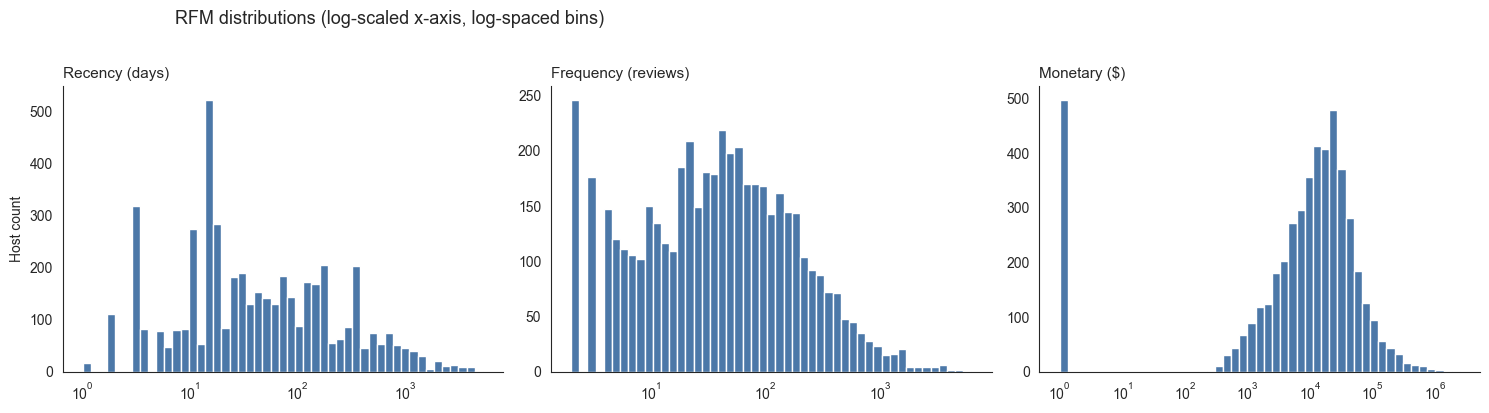

In [11]:
# Histogram of each RFM dimension, log-scaled x-axis.
# Bins are generated with np.logspace so bin widths are uniform in log-space,
# producing a readable distribution shape rather than one dominant bar.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    ['Recency (days)', 'Frequency (reviews)', 'Monetary ($)']
):
    data = rfm[col] + 1   # +1 shift avoids log(0) for hosts at the zero boundary
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
    ax.hist(data, bins=bins, color='#4C78A8', edgecolor='white')
    ax.set_xscale('log')
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('Host count' if col == 'recency' else '')

plt.suptitle('RFM distributions (log-scaled x-axis, log-spaced bins)',
             fontsize=13, y=1.02, x=0.12, ha='left')
plt.tight_layout()
plt.savefig('outputs/fig_01_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution Shape: Numeric Evidence and Visual Confirmation

**Skew diagnostic from summary statistics.** In a symmetric distribution, the mean and median are approximately equal. A mean substantially larger than the median is a formal indicator of right-skew.

| Metric | Median | Mean | Ratio | Verdict |
|---|---|---|---|---|
| Recency | 33 days | 167.55 days | 5.1× | Strong right-skew |
| Frequency | 37 reviews | 121.57 reviews | 3.3× | Strong right-skew |
| Monetary | \\$12,150 | \\$29,235 | 2.4× | Moderate right-skew |

**Tail severity.** The gap between the 75th percentile and the maximum reveals how extreme the tail values are. In a well-behaved distribution, the maximum is typically 2–3× the 75th percentile. All three RFM dimensions exceed this threshold by wide margins (Recency 37×, Frequency 57×, Monetary 88×), confirming the presence of substantial outlier populations within the host base.

**Visualization choices.** Histograms are plotted with a logarithmic x-axis because the raw values span multiple orders of magnitude (Recency 0–5,293 days; Monetary \\$0–\\$2.47M). Bin edges are generated via `np.logspace` to ensure uniform bin widths in log-space, and a +1 shift on raw values avoids undefined `log(0)` for hosts at the zero boundary. The underlying data is unchanged — only the visual scale is adjusted to make the shape readable.

**Findings by dimension.**

**Recency.** Summary statistics indicated heavy right-skew, with the median at 33 days against a mean of 167.55 days. The histogram confirms a large active core concentrated in the 10–100 day range with a pronounced peak near 20–30 days, tapering sharply toward the 1,000+ day region where long-dormant hosts sit. The gap between the active core and the dormant cluster is where *at-risk* hosts — those trending toward dormancy — will be identified during segmentation.

**Frequency.** The mean-to-median ratio of 3.3× signaled right-skew, and the histogram reveals a broadly unimodal distribution peaking around 30–100 lifetime reviews. The long tail extending to the thousands represents the small population of professional or high-volume operators. The shape is approximately log-normal — right-skewed on a linear scale but approximately symmetric when log-transformed, a common signature of engagement metrics.

**Monetary.** The summary statistics alone suggested moderate right-skew (2.4× ratio), but the histogram reveals a structural feature the numbers hid: **the distribution is bimodal**. A large spike near zero represents hosts with review history but no trailing-year revenue, while a well-defined log-normal bulk centered around \\$10,000–\\$30,000 captures the core revenue-generating population. This bimodality will have direct implications for K-Means clustering in Section 7, where the zero-revenue group is expected to emerge as a distinct cluster rather than blend with low-revenue active hosts.

**Methodological conclusion.** The combination of numeric and visual evidence establishes two conclusions that govern Section 3:

1. All three RFM dimensions are strongly right-skewed, validating **quintile scoring** (rank-based, equal-count bucketing) as the appropriate method. Equal-width binning would place the vast majority of hosts in the lowest bucket and leave upper buckets nearly empty, defeating the purpose of the scoring.
2. The bimodal Monetary distribution is a genuine feature of the data, not an artifact of the visualization. It will be preserved through scoring and surfaced more clearly during clustering.

## 3. Quintile Scoring

### Objective
Convert the three raw RFM values into a normalized 1–5 scale by ranking hosts and dividing them into equal-sized quintiles. The output is a score per dimension per host, where 5 represents top-performing and 1 represents bottom-performing.

### Methodology

**Rank-based, not value-based.** Quintile scoring sorts hosts by each dimension independently and assigns scores based on rank position, not raw value. This handles the right-skewed distributions validated in Section 2 — each quintile contains approximately 20% of hosts regardless of how extreme the tail values are.

**Direction of scoring.** For Frequency and Monetary, higher raw values are better, so higher raw values map to higher scores. For Recency, lower raw values are better (fewer days since last review = more recent activity), so the scoring is inverted — low Recency maps to score 5, high Recency maps to score 1.

**Composite RFM score.** After individual dimension scoring, a concatenated string score (e.g., `"555"` or `"143"`) is produced for each host. This composite is the input for rule-based segmentation in Section 4.

### Deliverable
Three new columns on the `rfm` dataframe — `R_score`, `F_score`, `M_score`, each an integer 1–5 — plus a `RFM_score` string concatenating the three.

In [13]:
# Quintile scoring: rank hosts on each dimension, divide into 5 equal-sized buckets.
# pd.qcut performs quantile-based discretization (equal-count bucketing).
#
# Recency is inverted: lower raw value (recent activity) = higher score.
# Frequency and Monetary use direct scoring: higher raw value = higher score.

# Recency: reverse label order because low recency is good
rfm['R_score'] = pd.qcut(rfm['recency'],
                         q=5,
                         labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: standard scoring, but rank first to handle tied values cleanly
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                         q=5,
                         labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: same treatment as Frequency
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                         q=5,
                         labels=[1, 2, 3, 4, 5]).astype(int)

# Composite RFM score as a 3-character string (e.g., "555", "143")
rfm['RFM_score'] = (rfm['R_score'].astype(str)
                    + rfm['F_score'].astype(str)
                    + rfm['M_score'].astype(str))

# Preview
print(f"Scored dataset shape: {rfm.shape}\n")
rfm[['host_id', 'host_name', 'recency', 'frequency', 'monetary',
     'R_score', 'F_score', 'M_score', 'RFM_score']].head(10)

Scored dataset shape: (4829, 11)



,host_id,host_name,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,23,Charlene,331,59,828.00,1,4,1,141
1,796,Betty,9,64,"12,528.00",5,4,3,543
2,8028,Sylvia,14,708,"14,550.00",4,5,3,453
3,12409,Flip,15,65,"5,712.00",4,4,2,442
4,12449,Solcrisalva Yasmin,9,7,"8,694.00",5,1,3,513
5,14156,Amy,27,339,"13,440.00",3,5,3,353
6,21279,Eric,68,22,"1,392.00",2,2,1,221
7,25298,Karen,134,54,304.00,2,3,1,231
8,37329,Jill,188,12,"1,530.00",1,2,1,121
9,44487,Christina F,14,1070,"58,044.00",4,5,5,455


### Quintile Scoring Output

**Structure of the scored dataset.** The `rfm` dataframe now carries four new columns: `R_score`, `F_score`, and `M_score` (each an integer from 1 to 5) plus the composite `RFM_score` string. Each host has been independently ranked on all three dimensions, with scores assigned by quintile position.

**Interpretation of the sample output.** The first ten rows illustrate the full range of host profiles the scoring produces:

| Host | Raw R | Raw F | Raw M | Score | Profile |
|---|---|---|---|---|---|
| Charlene | 331 | 59 | \\$9,828 | 1-4-1 | Dormant, historically active, low current revenue |
| Betty | 9 | 64 | \\$12,528 | 5-4-3 | Recently active, above-median engagement and revenue |
| Sylvia | 14 | 708 | \\$14,550 | 4-5-3 | Near-current activity, very high lifetime reviews, moderate revenue |
| Flip | 15 | 65 | \\$5,712 | 4-4-2 | Recently active, moderate engagement, below-median revenue |
| Yasmin | 9 | 7 | \\$8,694 | 5-1-3 | Recently active but low lifetime engagement — likely a newer host with reviews |
| Amy | 27 | 339 | \\$13,440 | 3-5-3 | Mid-recency, very high engagement, moderate revenue |
| Eric | 68 | 22 | \\$1,392 | 2-2-1 | Moderately dormant, low engagement, bottom-quartile revenue |
| Karen | 134 | 54 | \\$304 | 2-3-1 | Significantly dormant, moderate engagement, negligible revenue |
| Jill | 188 | 12 | \\$1,530 | 1-2-1 | Deeply dormant, low engagement, low revenue |
| Christina F | 14 | 1,070 | \\$58,044 | 4-5-5 | Recently active, top-quartile engagement, top-quartile revenue |

**Reading the composite score.** The three-digit RFM score (e.g., `"455"`) reads left-to-right as Recency-Frequency-Monetary. A host scoring `"555"` is top quintile on every dimension — a Champion. A host scoring `"111"` is bottom quintile on every dimension — Lost. The sample above demonstrates the scoring correctly places hosts across this range, from Jill's `"121"` at the low end to Christina F's `"455"` near the top.

**Validation of the scoring logic.** Two behaviors confirm the quintile cuts worked as intended:

1. **Recency inversion is correct.** Hosts with very low raw Recency (Betty at 9 days, Yasmin at 9 days) received score 5; hosts with high raw Recency (Charlene at 331 days, Jill at 188 days) received score 1. Lower raw values mapped to higher scores, as designed.
2. **Frequency and Monetary ordering is correct.** Christina F at 1,070 reviews received score 5; Yasmin at 7 reviews received score 1. Higher raw values mapped to higher scores, as designed.

**Forward linkage to Section 4.** The `RFM_score` string becomes the input for rule-based segmentation. Specific digit combinations will be mapped to named business segments (Champions, At Risk, Hibernating, Lost, etc.), translating the 125 possible score combinations into a small number of actionable groups.


In [14]:
# Verify that each quintile contains approximately 20% of hosts per dimension.
# Any substantial imbalance would indicate a problem with the scoring logic.

print("Hosts per quintile by dimension")
print("=" * 50)
distribution = pd.DataFrame({
    'R_score': rfm['R_score'].value_counts().sort_index(),
    'F_score': rfm['F_score'].value_counts().sort_index(),
    'M_score': rfm['M_score'].value_counts().sort_index()
})
distribution['Expected'] = int(len(rfm) / 5)
distribution

Hosts per quintile by dimension


,R_score,F_score,M_score,Expected
1,966,966,966,965
2,956,966,966,965
3,950,965,965,965
4,906,966,966,965
5,1051,966,966,965
